### Goal of the project
In Asian Options, the value of the call option at expiry is given by : <br>  $\max(\text{avg}(S) - K,0)$ <br> 
where we take the average of the stock in a given time interval. <br>
We need to find out the value of the call option. We do it using Monte Carlo assuming that the underlying follows GBM. We will also demonstrate the number of iterations and speed of convergence after applying both control variates and antithetic variates. The appropriate choices for control variates are those which have a closed form solution. Hence suitable choices are geometric Asian, European, and a combination of both of these ( multi control). We benchmark and plot graphs displaying the convergence. 

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import math

### Monte Carlo Method for Asian Options 
We now explain the procedure for a standard Monte Carlo method.
1) Assume that the stock price follows a GBM ( Geometric Brownian Motion ).
2) The Brownian Motion has independent normal increments, we label it as Z. We use Z and given the number of steps, ( by M ) and the number of simulations N, we create a matrix Z of size N*M where each of the element is chosen from a random normal sample. So we can think of the first row as choosing M elements from a std normal.
3) To simulate the brownian path, we need to add the columns appropriately, ( as $B_{t_{i+1}} - B_{t_i}$ is $N(0,t_{i+1}-t_i)$ ). This is done in increments.
4) Since $ S_t = S_0 * e^{(r-\sigma^2/2)t + \sigma B_t} $ we need to exponentiate.
5) Recall that the price of Asian option under fixed strike at maturity is $\max(S_{avg} - K,0)$. So we compute the average and payoffs
6) Finally, we compute the mean and the standard deviation to use CLT. <br>

The power of numpy is exemplified in Steps 3 and 4, where the operations are vectorised. Hence there is no need of for loops :-) <br>

We however present our situation in such a way that we have access to the computation of control variates as well. The usual control variate is Geometric Asian Option. Another option (less desirable) is Pricing of European Call option.

In [2]:
def simulate_asian_arithmetic_geometric_and_european(S0: float, r: float, sigma: float, T: float, n_steps: int, n_sims: int,
                                        rng=None,antithetic:bool=False):
    """
    Simulate n_sims independent GBM paths at n_steps monitoring times (equally spaced),
    return per-path arithmetic and geometric averages of the monitored prices. 
    This is introduced for the purpose of control variate technique in pricing Asian options which we discuss later.
    I am also using rng for making the result deterministic for testing purposes.
    """
    if rng is None:
        rng = np.random.default_rng() # Setting up the default random number generator
    dt = T / n_steps
    Z = rng.standard_normal(size=(n_sims, n_steps)) # Z shape(n_sims, n_steps)
    if antithetic:
        Z = np.vstack((Z, -Z)) # creating antithetic variates by stacking in the negative of Z just below Z
        n_sims *= 2 # The number of rows is doubled.
    increments = (r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z
    # cumulative log returns; logS_t = sum_{k<=t} increments
    logS = np.cumsum(increments, axis=1) # Since the number of columns is n_steps, cumulative sum is done along axis=1
    S = S0 * np.exp(logS)                # shape of S is (n_sims, n_steps)
    arith_mean = S.mean(axis=1)
    geom_mean = np.exp(np.mean(np.log(S), axis=1))
    return arith_mean, geom_mean, S[:,-1] # With geometric mean and terminal price as control variates

In [3]:

def Monte_Carlo_Standard(arith_mean: np.ndarray,K,r:float,T:float,n_sims:int):
    """ 
    Does standard Monte Carlo for Asian Arithmetic Average Price Call Option 
    For non-iteration purpose, decided to use simulate_asian_arithmetic_geometric function as it does the same thing.
    """
    discount=np.exp(-r * T)
    payoffs = np.maximum(arith_mean - K, 0) 
    # Monte Carlo estimator
    price = discount * np.mean(payoffs)
    stderr = discount * np.std(payoffs, ddof=1) / np.sqrt(n_sims)
    print(f"Asian Call Option Price: {price:.4f}")
    print(f"Standard Error: {stderr:.4f}")
    results = {
            "Type of Control Variate": "None",
            "price_after_control variate": price,
            "err_after_control variate": stderr,
            "b_hat": 0,
            "n_sims": n_sims
        }
    return(results);

In [4]:
S0 = 100.0
K  = 90.0
r  = 0.05
sigma = 0.30
T = 1
n_steps=50; # No of steps
n_sims=10;
rng = np.random.default_rng(12)   # Using a fixed seed for reproducibility
DATA_MONTE=pd.DataFrame(columns=["Iterations","Option Price","Standard Error"]);
i=0;
while(n_sims<=10**6):
    arith_mean,geometric_mean,terminal_price= simulate_asian_arithmetic_geometric_and_european(S0, r, sigma, T, n_steps, n_sims, rng, antithetic=False)
    L=Monte_Carlo_Standard(arith_mean,K,r,T,n_sims);
    DATA_MONTE.loc[i]=[n_sims]+[L["price_after_control variate"], L["err_after_control variate"]];
    i+=1;
    n_sims*=10;
print(DATA_MONTE);

Asian Call Option Price: 16.6337
Standard Error: 3.8246
Asian Call Option Price: 14.5794
Standard Error: 1.4561
Asian Call Option Price: 15.2480
Standard Error: 0.5109
Asian Call Option Price: 13.7347
Standard Error: 0.1481
Asian Call Option Price: 13.9976
Standard Error: 0.0474
Asian Call Option Price: 14.0664
Standard Error: 0.0150
   Iterations  Option Price  Standard Error
0        10.0     16.633704        3.824608
1       100.0     14.579401        1.456093
2      1000.0     15.247972        0.510921
3     10000.0     13.734733        0.148055
4    100000.0     13.997560        0.047389
5   1000000.0     14.066369        0.014964


#### Explanation for Closed form Solution of Geometric Mean Asian Price Option 
Now we use control variate technique to reduce the number of iterations to achieve faster mean.
In order to do this, we first note that we have a closed form solution for Geometric average of asian options. We write 
<br> $A_{G_n} = \bigg(\prod_{i=1}^n(S_{i})\bigg)^{1/n}$.<br>
If we assume that $$R_{i} =\frac{S_{i+1}}{S_{i}} \sim N((r - \sigma^2/2)\Delta t,\sigma^2 \Delta t)$$
We see that ( after some calculus )
$$ \ln(A_{G_n}/S(t))= \ln(S(T_0)/S(t)) + \frac{1}{n}\sum_{i=0}^{n-1}(n-i)\ln(R_i) $$
Using independence and normal distribution of $\ln(R_i)$ and $\ln(S(t_0)/S(t))$ we see that $\ln(A_{G_n}/S(t))$ is normally distributed. Each $\ln(R_i)$ has mean $\big(r - \sigma^2/2\big) \Delta t =  \big(r - \sigma^2/2\big) * T/N$. Substituting this, we see that the Mean and Variance of $\ln(A_{G_n}/S(t))$ are given by:
$$ \text{ mean } = (r - \frac{\sigma^2}{2})(\frac{n+1}{2n})(T-T_0)$$
$$ \text{ variance } = \sigma^2 \frac{(n + 1) (2n + 1)}{6n^2} (T-T_0)$$
(From Nicholas Privault, Asian Options book, Pg 185 and Pg 208 Ex 10.5) --> Need to do it in detail and write the solution in a report. 

In continuous form, this geometric average can be approximated in the following way : 
$$A_{G_n} \sim \text{exp}(\frac{1}{T} \int_{0}^T \log S_u du ).$$
This leads to computing the option price $e^{-rT} E^\mathbb{Q}[(A_{G_n} - K)^+]$ where we compute the expectation under risk neutral probability. We need to compute this in the following way (with the stock price given by $S_t = S_0 e^{(r - \frac{v}{2})t + \sqrt{v}B_t}$:
For $ X \sim N(0,v)$ we have
$$E^\mathbb{Q}[(e^{m+X} -K)^+] = e^{m+\frac{v}{2}} N(d_1) - K N(d_2)$$
where $d_1 = v+ \frac{m-\ln(K)}{\sqrt{v}} $ and $d_2 = d_1 - \sqrt{v}$
We just do this computation in geo_asian_price_discrete

In [5]:
def geo_asian_price_discrete(S0, K, r, sigma, T, n):
    """ 
    Closed-form geometric Asian price (discrete sampling) --> I am stuck at deriving this.
    Analytic price for a discrete-time geometric-average Asian call with equally spaced monitoring times t_i = i * T/n, i = 1..n.
    Returns Black Scholes type price: e^{-rT} (E[G] Phi(d1) - K Phi(d2)) where ln G ~ N(m, v).
    """
    m = math.log(S0) + (r - 0.5 * sigma**2) * (T *(n+1)/(2*n))
    v = sigma**2 * T *((n+1)*(2*n+1)/(6*n**2))
    d1 = (m + v - math.log(K))/math.sqrt(v)
    d2 = (m-math.log(K))/math.sqrt(v)
    EG = math.exp(m + 0.5 * v)
    price = math.exp(-r * T) * (EG * norm.cdf(d1) - K * norm.cdf(d2))
    return price
def european_black_scholes_call(S0, K, r, sigma, T):
    """ Standard European Call option price using Black Scholes formula """
    d1 = (math.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    price = S0 * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)
    return price    

#### Explanation For control Variates. 
We now explain the control variate method briefly. This information can be found in the book of Glassermann Monte Carlo Methods in Finance Engineering Chapter 4.
1) Monte Carlo Method is useful for finding the mean of a random variable $Y$ using the central limit theorem and law of large numbers. If $Y_i \sim Y$ are iid then for large values of $n$, we have $\overline{Y}_n:=\frac{1}{n} \sum_{i=1}^n Y_i \sim N(\mu,\frac{\sigma^2}{n})$ where $\mu$ and $\sigma^2$ are the mean and variances of $Y$ respectively.
2) In practice, if $\sigma$ is very high, then the above method is infeasible in finding the mean as we need a large number of simulations to reduce the error. Our mean is unknown at this point and this needs to be estimated.
3) We want to compute $E[Y]$ and we approximate it with $E[X]$ whose mean $\mu_X$ and covariance with $Y$ (abbbreviated as $\sigma_{XY}$) is known. So we write $$ E[\overline{Y}_n] = E[\overline{Y}_n - \beta( \overline{X}_n - \mu_X)]$$. By linearity of expectation, we see that this will go to $\mu_Y$. We optimize for $\beta$ such that the variance of $\overline{Y}_n + \beta( \overline{X}_n - \mu_X)$ is minimum. Expanding the term and applying the derivative test, we find that
   $$ \beta = \frac{\sigma_{XY}}{\sigma_X^2} $$
4) Now we explain how we do the simulation in practice. We first compute arithmetic and geometric mean over a fixed number of trials ( step size n ). This corresponds to how many terms that has to be taken for an average.
5) To do these computations, first we need to compute the terminal payoff. The formula is the same for any derivative_price. Second, we need to compute the component $X_n - \mu_X$. This is done by finding the theoretical values (for Geometric Asian and European Options). Finally, we do the computation of $\beta$ in the class which we describe after this section. 

In [6]:
def compute_terminal_payoff(derivative_price_at_end, K, r, T):
    # Discounted payoffs for a call on the averages. Since there are n_sims simulations, all the arrays are n_sims * 1 col arrays
    payoff = np.exp(-r * T) * np.maximum(derivative_price_at_end - K, 0)  
    return payoff;
def compute_control_parameters_mean0(S0,K,r,sigma,T,number_of_steps,payoff,label):
    if label=="Geometric Asian":
        theoretical_value=geo_asian_price_discrete(S0, K, r, sigma, T,number_of_steps); # Why is n_sims required here?   
    elif label=="European":
        theoretical_value=european_black_scholes_call(S0, K, r, sigma, T);
    return payoff-theoretical_value;
# -------------------------
# Utility: running mean (Useful for graph plotting)
# -------------------------
def running_mean(arr):
    return np.cumsum(arr) / (np.arange(len(arr)) + 1)

#### Introducing Class for control variate operations 
We define a class called `Pricing_parameters` which takes 2 arrays ( 1 array and a nd array ) as an argument along with a label. This is done for the purpose of benchmarking and computation simplification.

In the class, we define the following functions : <br>
a) Compute $\widehat{\beta}$, the appropriate coefficient to have for these parameters. <br>
b) Compute the required results and save it in a dataframe. <br> 
c) Using the computed $\widehat{\beta}$, we compute the running mean for plotting the convergence.  

Part c) is slightly inaccurate in practice, however computing $\widehat{\beta}_n$ for each instance $n$ of the running mean seems pointless. If one wants extreme precision, they can perhaps resort to moving average to compute the entries of the matrix, but this doesn't simplify the exposition in any way.

In [7]:
class Pricing_Parameters:
    """ A class to hold all the parameters required for pricing """
    def __init__(self, price_to_be_estimated:np.array, control_price:np.ndarray, label:str):
        self.price_to_be_estimated=price_to_be_estimated
        self.control_price=control_price
        self.label=label
    def control_variate_factors(self):
        """ 
        Function to compute control variate factors. Pricing parameters objects are two arrays of same length.
        Returns the optimal beta_hat for control variate.
        """
        data=np.vstack((self.price_to_be_estimated,self.control_price));
        cov_matrix = np.cov(data);
        cov_CX=cov_matrix[1:,0]; # Take entries from first column except first row
        cov_CC=cov_matrix[1:,1:]; # Take submatrix of second row and second column onwards
        beta_hat=np.linalg.pinv(cov_CC)@cov_CX;
        beta_hat=beta_hat.reshape(-1); # Reshaping into a column vector
        return beta_hat 
    def compute_params_mc_asian_with_control_variate(self):
        """
        We compute the Monte carlo parameters and control variate parameters.   
        """
        # Estimate optimal coefficient \beta_ag (cov/geo_var)
        b_hat = self.control_variate_factors(); 
        # Apply control variate 
        # Not an ideal way of doing it but works for now
        if self.control_price.ndim == 1:
            payoffs = self.price_to_be_estimated - b_hat * (self.control_price)
        else:
            payoffs = self.price_to_be_estimated - b_hat @ (self.control_price)
        cv_mean = payoffs.mean()
        cv_se = payoffs.std(ddof=1)/math.sqrt(len(payoffs))
        
    
        results = {
            "Type of Control Variate": self.label,
            "price_after_control_variate": cv_mean,
            "err_after_control_variate": cv_se,
            "b_hat": b_hat,
            "n_sims": len(self.price_to_be_estimated)
        }

        return results
    def compute_running_mean(self,length:int):
        """
        Computes the running mean of the price to be estimated after applying the control variate.
        """
        reqd_length=min(length,len(self.price_to_be_estimated));
        b_hat=self.control_variate_factors();
        if self.control_price.ndim == 1:
            payoffs = self.price_to_be_estimated[:reqd_length] - b_hat * (self.control_price[:reqd_length])
        else:
            payoffs = self.price_to_be_estimated[:reqd_length] - b_hat @ (self.control_price[:,:reqd_length])
        running_mean_price = running_mean(payoffs)
        return running_mean_price


##### Instructions for proceeding further
This is a set of instructions on how I will use the functions that I defined so far.
1) Recall that simulate_asian_arithmetic_geometric_european simulates the arithmetic geometric and terminal values n_sims times.
2) Using this, we compute the terminal payoffs and control parameters with mean 0.
3) With the help of the class function, we compute the variance and estimated price for each of the control variates.

In [8]:

# Parameters (edit as needed)
S0 = 100.0
K  = 90.0
r  = 0.05
sigma = 0.30
T = 1
n_sims = 1000000 # total Monte Carlo paths (e.g., 100k, 200k, 1M depending on CPU/time)
n_steps=50;     
rng = np.random.default_rng(12)

In [9]:
# We now put everything together
# Step 1) Given a Monte Carlo simulation of the paths, compute the respective objects
asian_arithmetic,asian_geometric,european=simulate_asian_arithmetic_geometric_and_european(S0, r, sigma, T, n_steps, n_sims, rng, antithetic=False)
# Step 2) Compute the terminal payoffs
asian_geometric_payoff=compute_terminal_payoff(asian_geometric,K,r,T);
european_payoff=compute_terminal_payoff(european,K,r,T);
asian_arithmetic_payoff=compute_terminal_payoff(asian_arithmetic,K,r,T);
# Step 3) Compute the control variate parameters ( with mean 0 )
geometric_parameter=compute_control_parameters_mean0(S0,K,r,sigma,T,n_steps,asian_geometric_payoff,"Geometric Asian");
european_parameter=compute_control_parameters_mean0(S0,K,r,sigma,T,n_steps,european_payoff,"European");
# Step 4) Define the class objects and compute the parameters here
Geometric=Pricing_Parameters(asian_arithmetic_payoff,geometric_parameter,"Geometric Asian");
European=Pricing_Parameters(asian_arithmetic_payoff,european_parameter,"European");
Combined=Pricing_Parameters(asian_arithmetic_payoff,np.vstack((geometric_parameter,european_parameter)),"Mixed Control Variate");
Standard=Pricing_Parameters(asian_arithmetic_payoff,np.zeros(len(asian_arithmetic_payoff)),"Standard MC");

# We reiterate the same steps for antithetic variates now.
antithetic_asian_arithmetic,antithetic_asian_geometric,antithetic_european=simulate_asian_arithmetic_geometric_and_european(S0, r, sigma, T, n_steps, n_sims, rng, antithetic=True)
# Step 2.1) Compute the terminal payoffs
antithetic_asian_geometric_payoff=compute_terminal_payoff(antithetic_asian_geometric,K,r,T);
antithetic_european_payoff=compute_terminal_payoff(antithetic_european,K,r,T);
antithetic_asian_arithmetic_payoff=compute_terminal_payoff(antithetic_asian_arithmetic,K,r,T);
# Step 3.1) Compute the control variate parameters ( with mean 0 )
antithetic_geometric_parameter=compute_control_parameters_mean0(S0,K,r,sigma,T,n_steps,antithetic_asian_geometric_payoff,"Geometric Asian");
antithetic_european_parameter=compute_control_parameters_mean0(S0,K,r,sigma,T,n_steps,antithetic_european_payoff,"European");
# Step 4.1) Define the class objects and compute the parameters here
Antithetic_Standard=Pricing_Parameters(antithetic_asian_arithmetic_payoff,np.zeros(len(antithetic_asian_arithmetic_payoff)),"Antithetic Standard MC");
Antithetic_Geometric=Pricing_Parameters(antithetic_asian_arithmetic_payoff,antithetic_geometric_parameter,"Antithetic Geometric Asian");
Antithetic_European=Pricing_Parameters(antithetic_asian_arithmetic_payoff,antithetic_european_parameter,"Antithetic European");
Antithetic_Combined=Pricing_Parameters(antithetic_asian_arithmetic_payoff,np.vstack((antithetic_geometric_parameter,antithetic_european_parameter)),"Antithetic Mixed Control Variate");


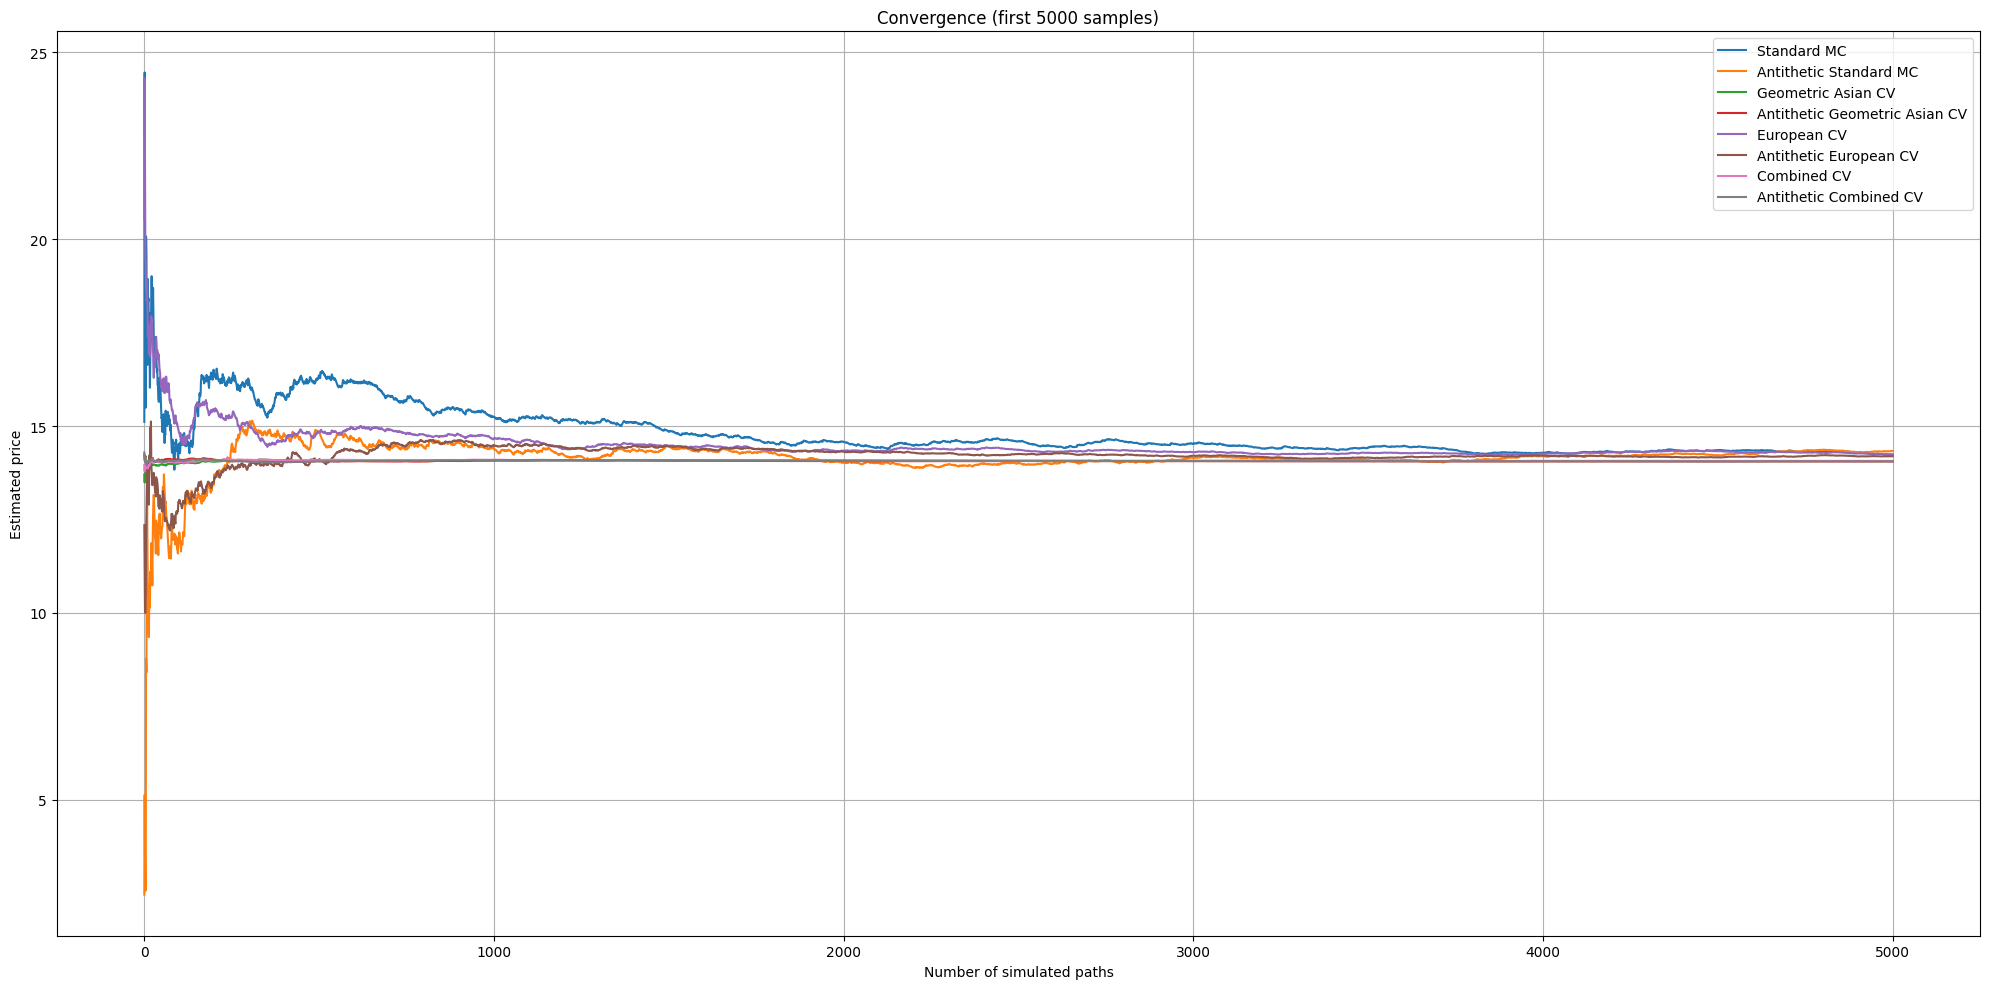

In [10]:
""" Visualization of convergence - 5000 sample paths for better understanding """
# Convergence plot (first up to 50k samples to keep line smooth)
max_plot = min(5000, n_sims)

plt.figure(figsize=(20, 10))
LABELS=["Standard MC","Antithetic Standard MC","Geometric Asian CV","Antithetic Geometric Asian CV","European CV","Antithetic European CV","Combined CV","Antithetic Combined CV"]
PLOT_ARRAY=[Standard.compute_running_mean(max_plot),Antithetic_Standard.compute_running_mean(max_plot),Geometric.compute_running_mean(max_plot),Antithetic_Geometric.compute_running_mean(max_plot),European.compute_running_mean(max_plot),Antithetic_European.compute_running_mean(max_plot),Combined.compute_running_mean(max_plot),Antithetic_Combined.compute_running_mean(max_plot)]
for i in range(len(PLOT_ARRAY)):
    plt.plot(PLOT_ARRAY[i],label=LABELS[i])
"""
rm_plain = running_mean(asian_arithmetic_payoff[:max_plot])
rm_geometric = running_mean(asian_arithmetic_payoff[:max_plot]- Geometric.control_variate_factors()*geometric_parameter[:max_plot])
rm_european = running_mean(asian_arithmetic_payoff[:max_plot]- European.control_variate_factors()*european_parameter[:max_plot])
#rm_combined = running_mean(asian_arithmetic_payoff[:max_plot]- Combined.control_variate_factors()@np.vstack((geometric_parameter,european_parameter))[:max_plot])
plt.plot(rm_plain, label="plain MC running mean")
plt.plot(rm_geometric, label="Asian Geometric control-variate running mean")
plt.plot(rm_european, label="European control-variate running mean")
#plt.plot(rm_combined, label="Mixed control-variate running mean")
"""
plt.xlabel("Number of simulated paths")
plt.ylabel("Estimated price")
plt.title("Convergence (first {} samples)".format(max_plot))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
# Here we tabulate the result after performing Monte Carlo for n_sims simulations. 
results=[];
results.append(Standard.compute_params_mc_asian_with_control_variate());
results.append(Antithetic_Standard.compute_params_mc_asian_with_control_variate());
results.append(Geometric.compute_params_mc_asian_with_control_variate());
results.append(Antithetic_Geometric.compute_params_mc_asian_with_control_variate());
results.append(European.compute_params_mc_asian_with_control_variate());
results.append(Antithetic_European.compute_params_mc_asian_with_control_variate());
results.append(Combined.compute_params_mc_asian_with_control_variate());
results.append(Antithetic_Combined.compute_params_mc_asian_with_control_variate());
# Summary table
summary=pd.DataFrame(results,index=None);
summary["VR FACTOR"]=(summary.loc[0,"err_after_control_variate"]/summary["err_after_control_variate"])**2;
print(summary);

            Type of Control Variate  price_after_control_variate  \
0                       Standard MC                    14.048063   
1            Antithetic Standard MC                    14.059768   
2                   Geometric Asian                    14.066545   
3        Antithetic Geometric Asian                    14.066130   
4                          European                    14.053340   
5               Antithetic European                    14.064739   
6             Mixed Control Variate                    14.066235   
7  Antithetic Mixed Control Variate                    14.066147   

   err_after_control_variate                                       b_hat  \
0                   0.014957                                       [0.0]   
1                   0.010576                                       [0.0]   
2                   0.000552                         [1.037959724433047]   
3                   0.000390                         [1.037866041488519]   
4      